## 1. Creiamo il circuito con cui andremo a lavorare

In [18]:
from qiskit import QuantumCircuit, transpile

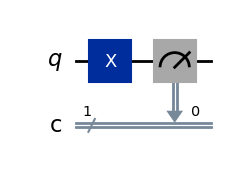

In [19]:
qc = QuantumCircuit(1, 1) # Definisco un circuito con un qubit e un bit classico (il bit classico mi serve per vedere un risultato)

qc.x(0) # Metto un gate X (invertitore) sul qubit con indice 0

qc.measure(0, 0) # Metto un gate Measure dal qubit di indice 0 al bit di indice 0 

qc.draw("mpl")

## 2. Otteniamo dei risultati

In [20]:
from qiskit_aer import AerSimulator

In [21]:
backend = AerSimulator()

compiled = transpile(qc, backend) # prende la ricetta astratta (qc) e la riscrive nel linguaggio che quel backend specifico (backend) sa eseguire davvero

job = backend.run(compiled, shots = 1024)

counts = job.result().get_counts() 

print(counts)


{'1': 1024}


## 3. Visualizziamo i risultati

In [22]:
from qiskit.visualization import plot_histogram

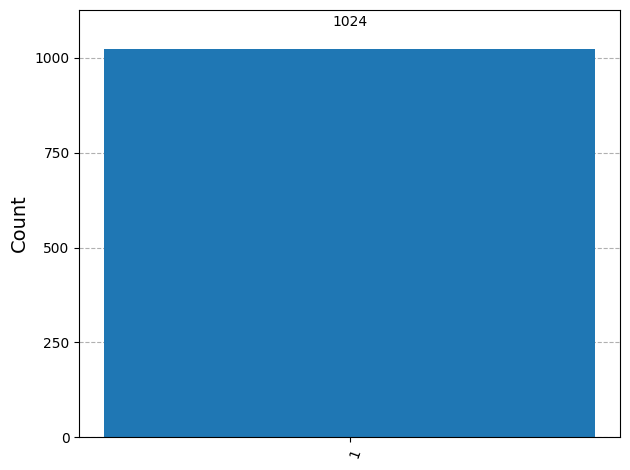

In [23]:
plot_histogram(counts)

# Quindi l'ordine logico è sempre: 
## 1. QuantumCircuit (progetti cosa vuoi fare) 
## 2. transpile (lo adatti al backend scelto) 
## 3. run (lo esegui) 
## 4. get_counts (leggi il risultato)